# Jour 7 — Analyse finale & Comparaison des runs

**Objectif :** comparer Day 6 (reward original) vs Day 7 (reward tuné) sur l'indicateur clé : `pct_safe`.

> ⚠️ Les returns **ne sont pas comparables** entre les deux runs — les pénalités ont changé de magnitude.  
> L'indicateur neutre est `pct_safe` (% de steps en zone thermique sûre).

In [7]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')


import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib

import os

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RUNS = {
    'Day 6 — original reward': '../runs/day6_curriculum',
    'Day 7 — tuned reward':    '../runs/day7_tuned',
}

## 1. Comparaison `pct_safe` — indicateur clé

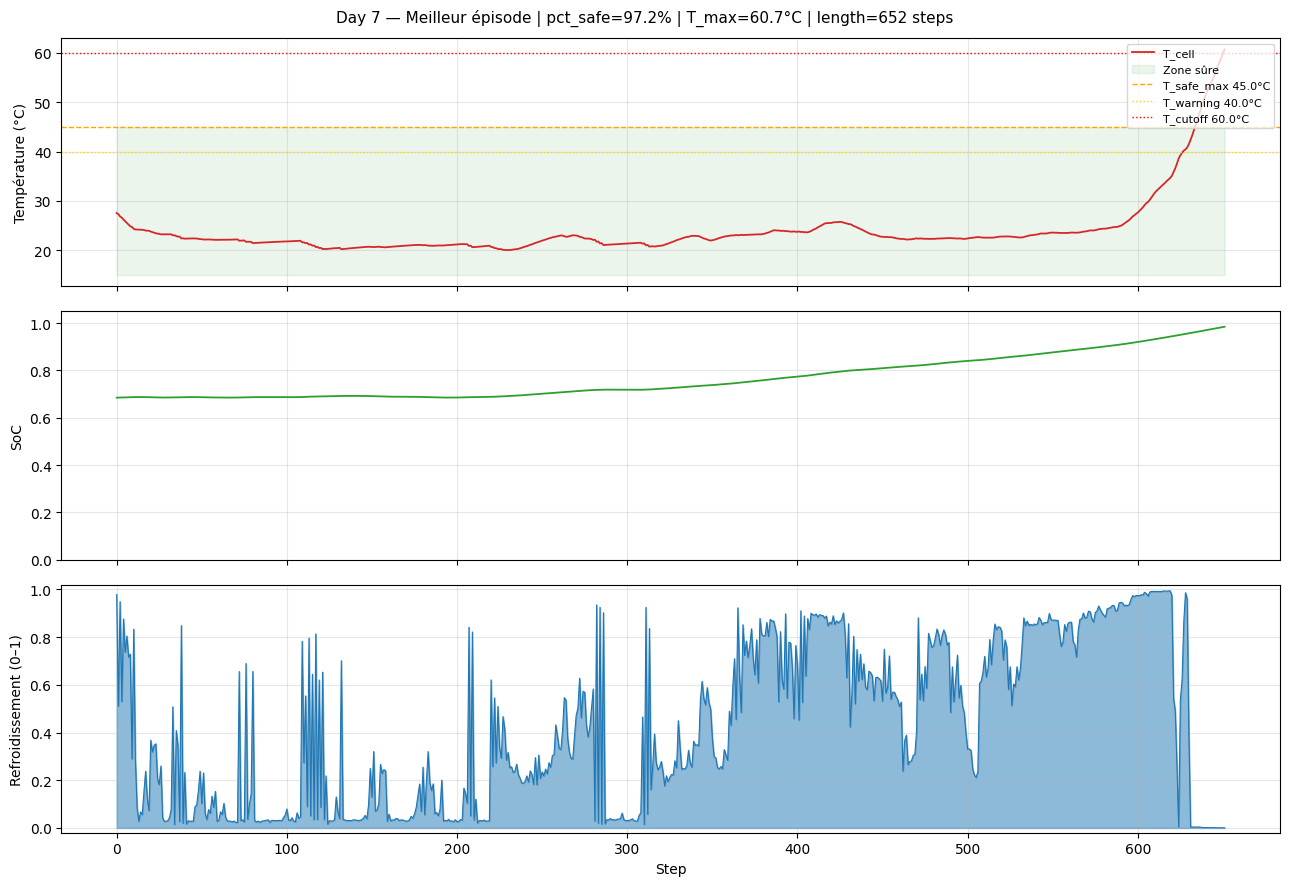

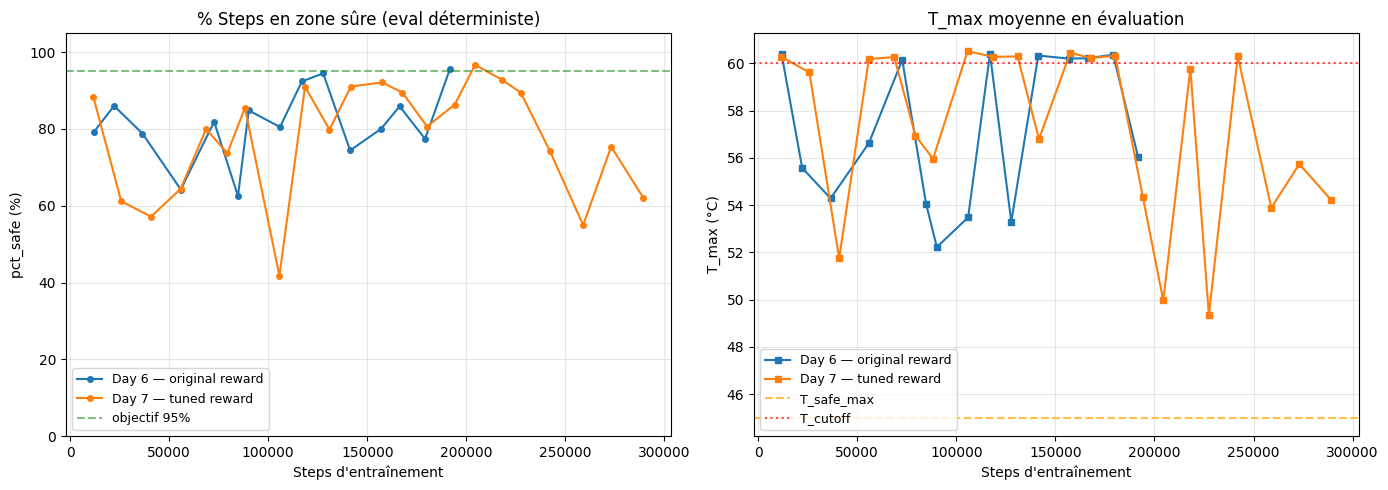

Sauvegardé → runs/comparison_day6_vs_day7.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['tab:blue', 'tab:orange']

for (label, run_dir), color in zip(RUNS.items(), colors):
    eval_path = os.path.join(run_dir, 'evals.csv')
    if not os.path.exists(eval_path):
        print(f'Fichier manquant : {eval_path}')
        continue
    df = pd.read_csv(eval_path)

    # pct_safe
    axes[0].plot(df['total_steps'], df['eval_pct_safe'],
                 marker='o', markersize=4, linewidth=1.5, label=label, color=color)

    # T_max
    axes[1].plot(df['total_steps'], df['eval_T_max_mean'],
                 marker='s', markersize=4, linewidth=1.5, label=label, color=color)

axes[0].set_title('% Steps en zone sûre (eval déterministe)')
axes[0].set_xlabel('Steps d\'entraînement')
axes[0].set_ylabel('pct_safe (%)')
axes[0].set_ylim(0, 105)
axes[0].axhline(95, color='green', linestyle='--', alpha=0.5, label='objectif 95%')
axes[0].legend(fontsize=9)

axes[1].set_title('T_max moyenne en évaluation')
axes[1].set_xlabel('Steps d\'entraînement')
axes[1].set_ylabel('T_max (°C)')
axes[1].axhline(45, color='orange', linestyle='--', alpha=0.7, label='T_safe_max')
axes[1].axhline(60, color='red',    linestyle=':',  alpha=0.7, label='T_cutoff')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../runs/comparison_day6_vs_day7.png', dpi=130)
plt.show()
print('Sauvegardé → runs/comparison_day6_vs_day7.png')

## 2. Tableau récapitulatif

In [9]:
summary_rows = []

for label, run_dir in RUNS.items():
    eval_path = os.path.join(run_dir, 'evals.csv')
    if not os.path.exists(eval_path):
        continue
    df = pd.read_csv(eval_path)
    last_10 = df.tail(10)  # moyenne sur les 10 dernières évals
    summary_rows.append({
        'Run':             label,
        'Steps total':     int(df['total_steps'].max()),
        'pct_safe max':    f"{df['eval_pct_safe'].max():.1f}%",
        'pct_safe (last 10 evals)': f"{last_10['eval_pct_safe'].mean():.1f}%",
        'T_max moy':       f"{last_10['eval_T_max_mean'].mean():.1f}°C",
        'Variance pct_safe': f"{df['eval_pct_safe'].std():.1f}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Run,Steps total,pct_safe max,pct_safe (last 10 evals),T_max moy,Variance pct_safe
0,Day 6 — original reward,191732,95.6%,82.8%,57.1°C,9.6
1,Day 7 — tuned reward,289361,96.7%,80.2%,55.8°C,14.9


## 3. Meilleur épisode — Day 7

In [10]:
from config import EnvConfig, ThermalConfig, RewardConfig
from envs.battery_thermal_env import BatteryThermalEnv
from evaluate import load_agent, run_episode

CHECKPOINT_D7 = '../runs/day7_tuned/checkpoints/sac_final.pt'

env_cfg = EnvConfig(thermal=ThermalConfig(), reward=RewardConfig())
env     = BatteryThermalEnv(config=env_cfg)

agent_d7 = load_agent(
    CHECKPOINT_D7,
    obs_dim    = env.observation_space.shape[0],
    action_dim = env.action_space.shape[0],
)

# 10 épisodes d'évaluation
results_d7 = [run_episode(agent_d7, env, seed=i) for i in range(10)]
best_d7    = max(results_d7, key=lambda r: r['pct_safe'])

print(f"Meilleur épisode — pct_safe={best_d7['pct_safe']:.1f}%  T_max={best_d7['T_max']:.1f}°C")

Meilleur épisode — pct_safe=97.2%  T_max=60.7°C


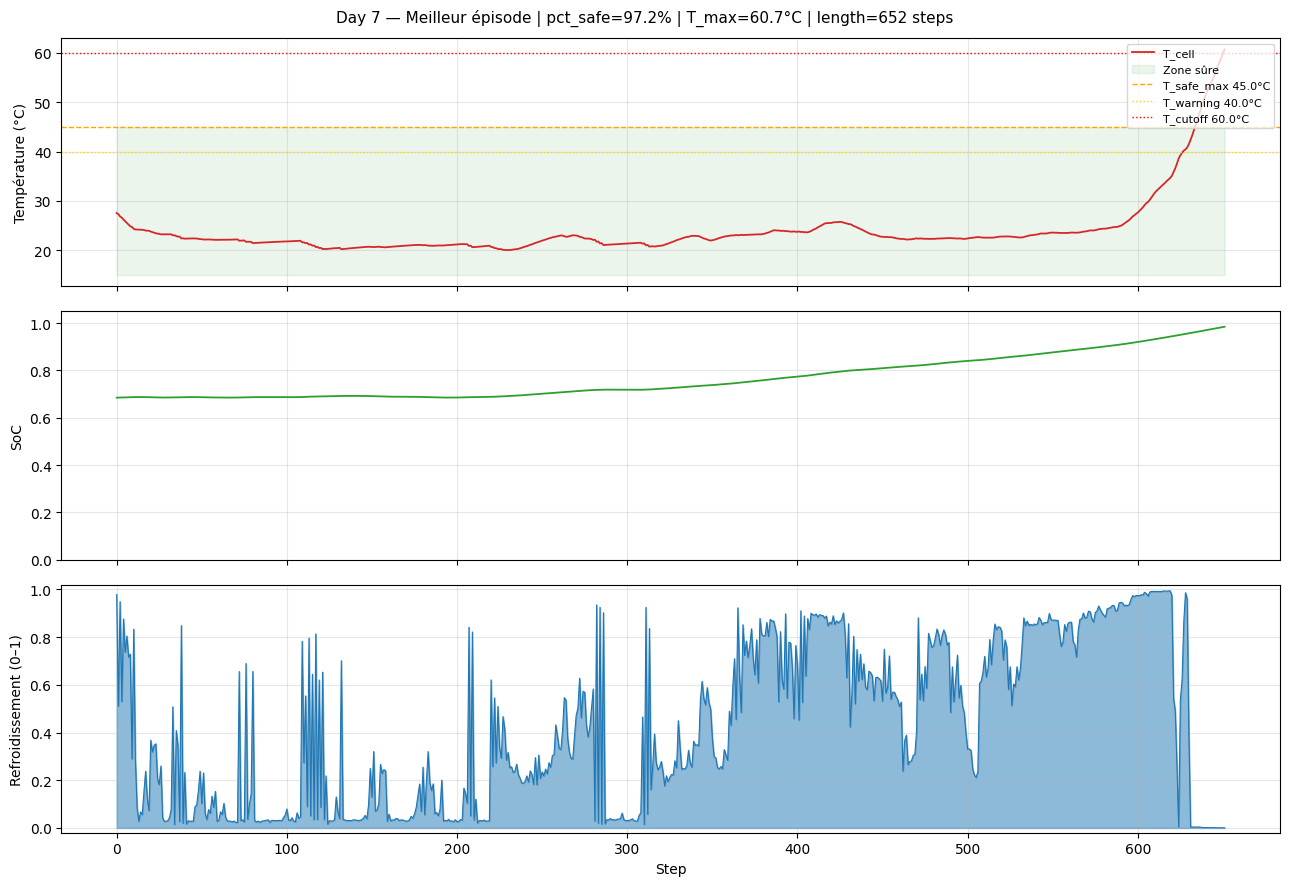

In [11]:
tc    = env.tc
steps = range(len(best_d7['T_hist']))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Température
ax = axes[0]
ax.plot(steps, best_d7['T_hist'], color='tab:red', linewidth=1.3, label='T_cell')
ax.fill_between(steps, tc.T_safe_min, tc.T_safe_max, alpha=0.08, color='green', label='Zone sûre')
ax.axhline(tc.T_safe_max, color='orange', linestyle='--', linewidth=1, label=f'T_safe_max {tc.T_safe_max}°C')
ax.axhline(tc.T_warning,  color='gold',   linestyle=':',  linewidth=1, label=f'T_warning {tc.T_warning}°C')
ax.axhline(tc.T_cutoff,   color='red',    linestyle=':',  linewidth=1, label=f'T_cutoff {tc.T_cutoff}°C')
ax.set_ylabel('Température (°C)')
ax.legend(fontsize=8, loc='upper right')

# SoC
ax = axes[1]
ax.plot(steps, best_d7['SoC_hist'], color='tab:green', linewidth=1.3)
ax.set_ylabel('SoC')
ax.set_ylim(0, 1.05)

# Action
ax = axes[2]
ax.fill_between(steps, 0, best_d7['action_hist'], color='tab:blue', alpha=0.5)
ax.plot(steps, best_d7['action_hist'], color='tab:blue', linewidth=0.8)
ax.set_ylabel('Refroidissement (0–1)')
ax.set_xlabel('Step')
ax.set_ylim(-0.02, 1.02)

fig.suptitle(
    f"Day 7 — Meilleur épisode | "
    f"pct_safe={best_d7['pct_safe']:.1f}% | "
    f"T_max={best_d7['T_max']:.1f}°C | "
    f"length={best_d7['length']} steps",
    fontsize=11
)
plt.tight_layout()
plt.savefig('../runs/day7_best_episode.png', dpi=130)
plt.show()

## 4. Bilan du challenge 7 jours

| Jour | Livrable | Statut |
|------|----------|--------|
| J1 | Environnement Gymnasium + modèle RC thermique | ✅ 17/17 tests |
| J2 | Agent SAC (Actor, Double Critic, entropie adaptative, replay buffer) | ✅ 22/22 tests |
| J3 | Boucle d'entraînement + reward shaping + logger CSV | ✅ |
| J4 | Évaluation déterministe + grid search hyperparamètres | ✅ |
| J5 | Baselines + comparaison | ✅ |
| J6 | Long run 200k steps — pct_safe jusqu'à 95.6% | ✅ |
| J7 | Reward tuning (w_delta_T) + run 300k — pct_safe jusqu'à 96.7% | ✅ |

### Points clés
- L'agent SAC apprend à maintenir ~95-97% du temps en zone thermique sûre
- La pénalité `dT/dt` (w_delta_T) donne un signal plus précoce sur les montées rapides
- La variance reste élevée → piste d'amélioration : entraînement plus long ou scheduler de learning rate

### Paramètres adaptables par l'utilisateur FSE
Tous dans `config.py` :
- `C_th`, `R_th`, `R_int` — propriétés thermiques de la batterie réelle
- `T_safe_max`, `T_warning`, `T_cutoff` — seuils opérationnels
- `w_temp_high`, `w_delta_T` — agressivité de la politique thermique